In [76]:
# Installation of required libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, roc_curve, auc
from imblearn.over_sampling import SMOTE # To balance benign samples in the dataset to malware
# from imblearn.under_sampling import RandomUnderSampler # To balance malware samples in the dataset to benign
import joblib


In [77]:
# Loading the Dataset
df = pd.read_csv("dataset.csv") 

# As the CSV has a column 'api_sequence' as its run on Cuckoo/CAPE as well
X_raw = df['api_sequence'] 
y = df['label']


In [78]:
# Converting APIs text to Numeric Features through TF-IDF
vectorizer = TfidfVectorizer(ngram_range=(1, 3), max_features=1000)
X = vectorizer.fit_transform(X_raw)

print(f"Original dataset shape: {y.value_counts().to_dict()}")


Original dataset shape: {1: 7986, 0: 101}


In [79]:
# Splitting the Data to train and test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [80]:
# Oversamples using smote
smote = SMOTE(random_state=42)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train, y_train)
print(f"Original training shape: {y_train.value_counts().to_dict()}")
print(f"Resampled training shape: {y_train_balanced.value_counts().to_dict()}")


Original training shape: {1: 6387, 0: 82}
Resampled training shape: {1: 6387, 0: 6387}


In [81]:
# Undersamples by RandomUnderSampler to make malware count same as benign count of samples
# rus = RandomUnderSampler(random_state=42)
# X_train_balanced, y_train_balanced = rus.fit_resample(X_train, y_train)


In [82]:
# Training the Random Forest Classifier 
model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1, class_weight='balanced')
model.fit(X_train_balanced, y_train_balanced)


,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [83]:
# Evaluating the Balanced Model
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

print(f"Accuracy: {accuracy_score(y_test, y_pred) * 100:.2f}%\n")
print(classification_report(y_test, y_pred))


Accuracy: 99.32%

              precision    recall  f1-score   support

           0       0.79      0.58      0.67        19
           1       1.00      1.00      1.00      1599

    accuracy                           0.99      1618
   macro avg       0.89      0.79      0.83      1618
weighted avg       0.99      0.99      0.99      1618



In [84]:
# Saving the Model and Vectorizer for use in Streamlit / predict.py
joblib.dump(model, "random_forest_model.pkl")
joblib.dump(vectorizer, "api_vectorizer.pkl")
print("Model saved")


Model saved


Saved 'confusion_matrix.png'


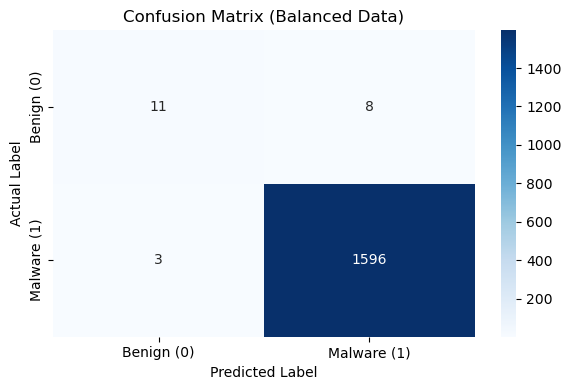

In [85]:
# Confusion Matrix
plt.figure(figsize=(6, 4))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Benign (0)', 'Malware (1)'], 
            yticklabels=['Benign (0)', 'Malware (1)'])
plt.title('Confusion Matrix (Balanced Data)')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.savefig('confusion_matrix.png')
print("Saved 'confusion_matrix.png'")

Saved 'roc_curve.png'


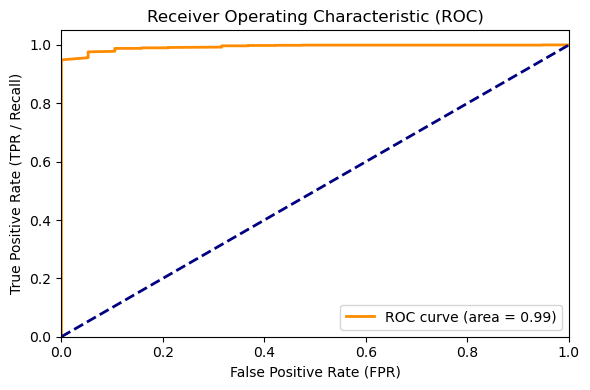

In [86]:
#Generating ROC-AUC Curve Chart
fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6, 4))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR / Recall)')
plt.title('Receiver Operating Characteristic (ROC)')
plt.legend(loc="lower right")
plt.tight_layout()
plt.savefig('roc_curve.png')
print("Saved 'roc_curve.png'")

In [87]:
# Saving the fully balanced models for integration
joblib.dump(model, "random_forest_model.pkl")
joblib.dump(vectorizer, "api_vectorizer.pkl")
print("Export complete")

Export complete
